# Assignment 7 - Spatial integration and field-level NDVI

This notebook joins each selected Story County field to its 2023 crop label, dominant SSURGO map unit, and Sentinel-2 field-level mean NDVI.

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
for parent in (ROOT, *ROOT.parents):
    if (parent / 'data/processed/assignment-07/integrated_field_summary.csv').is_file():
        ROOT = parent
        break

SUMMARY_PATH = ROOT / 'data/processed/assignment-07/integrated_field_summary.csv'
GEOJSON_PATH = ROOT / 'data/processed/assignment-07/integrated_fields.geojson'
FIGURE_PATH = ROOT / 'docs/assets/integrated_spatial_analysis.png'

## One-to-one field integration

In [2]:
summary = pd.read_csv(SUMMARY_PATH, dtype={'dominant_soil_mukey': str})
fields = gpd.read_file(GEOJSON_PATH)

assert len(summary) == 25 and summary['field_id'].nunique() == 25
assert len(fields) == 25 and fields.crs.to_epsg() == 4326
assert summary['field_id'].tolist() == sorted(summary['field_id'])
assert summary['field_id'].tolist() == fields['field_id'].tolist()
summary.head()

,field_id,crop_2023_name,dominant_soil,dominant_soil_name,dominant_soil_mukey,dominant_soil_overlap_area_ha,mean_ndvi,valid_pixel_count,total_pixel_count,ndvi_coverage_fraction
0,STORY-01,Soybeans,388,"Kossuth silty clay loam, 0 to 2 percent slopes",411315,6.404251,0.936531,1338,1338,1.0
1,STORY-02,Soybeans,95,"Harps clay loam, 0 to 2 percent slopes",411346,13.628296,0.942604,5023,5023,1.0
2,STORY-03,Corn,259,"Biscay clay loam, 0 to 2 percent slopes",411305,30.499095,1.000000,7531,7531,1.0
3,STORY-04,Soybeans,L138B,"Clarion loam, Bemis moraine, 2 to 6 percent sl...",2765537,6.203053,0.905365,1580,1580,1.0
4,STORY-05,Soybeans,L507,"Canisteo clay loam, Bemis moraine, 0 to 2 perc...",2922031,9.295463,0.761290,3095,3095,1.0


## Shared zonal statistics and valid-pixel coverage

Assignment 5 calculated field zonal statistics from cloud-masked Sentinel-2 pixels in the raster's native grid. No-data and invalid Scene Classification Layer pixels were excluded. `valid_pixel_count`, `total_pixel_count`, and `ndvi_coverage_fraction` are retained here as evidence for every field. A future field with insufficient imagery remains null rather than receiving an imputed `mean_ndvi`.

In [3]:
coverage = summary[['field_id', 'mean_ndvi', 'valid_pixel_count', 'total_pixel_count', 'ndvi_coverage_fraction']]
assert (coverage['valid_pixel_count'] <= coverage['total_pixel_count']).all()
assert coverage['ndvi_coverage_fraction'].between(0, 1).all()
coverage.describe().round(4)

,mean_ndvi,valid_pixel_count,total_pixel_count,ndvi_coverage_fraction
count,25.0000,25.0000,25.0000,25.0
mean,0.9418,3149.2800,3149.2800,1.0
std,0.0745,1716.8717,1716.8717,0.0
min,0.7613,758.0000,758.0000,1.0
25%,0.9054,1751.0000,1751.0000,1.0
50%,0.9833,2966.0000,2966.0000,1.0
75%,0.9997,3576.0000,3576.0000,1.0
max,1.0000,7531.0000,7531.0000,1.0


## Mean-NDVI map and descriptive group comparisons

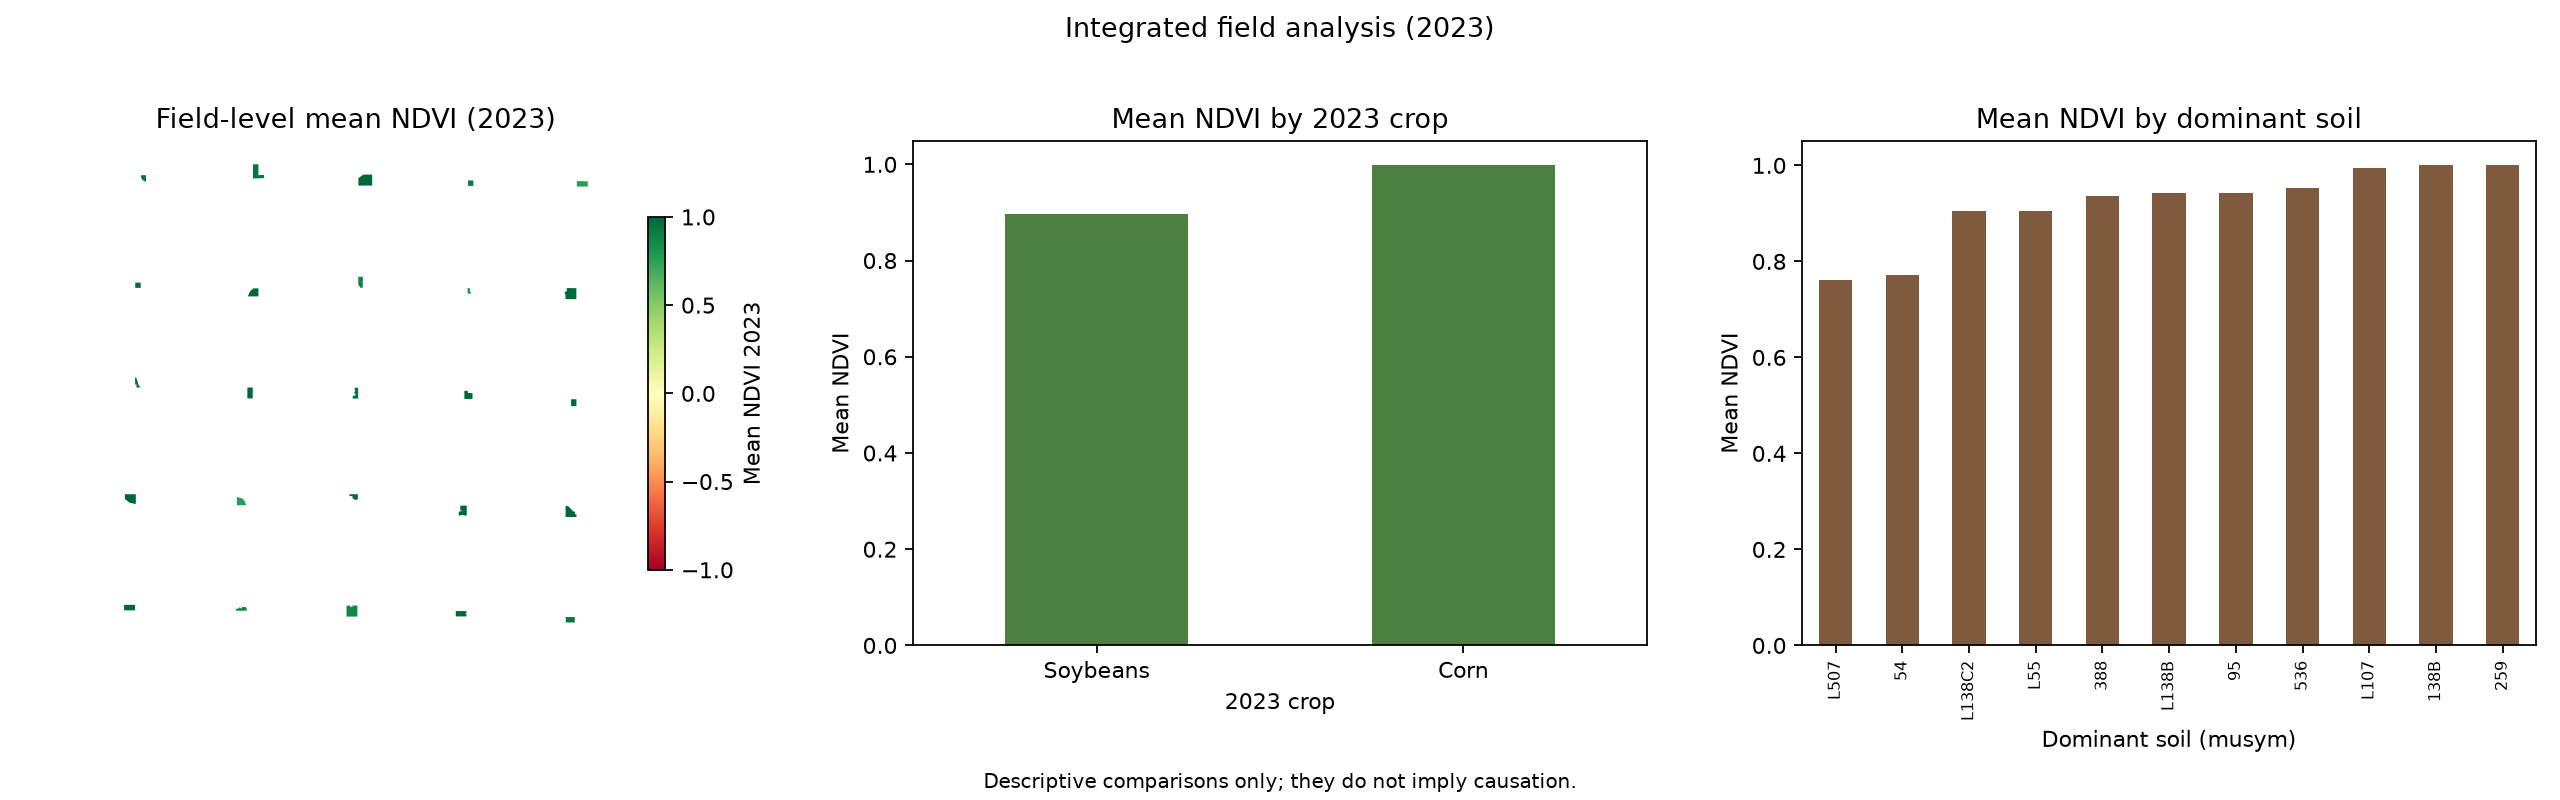

In [4]:
display(Image(filename=str(FIGURE_PATH)))

In [5]:
crop_comparison = summary.groupby('crop_2023_name').agg(
    fields=('field_id', 'size'), mean_ndvi=('mean_ndvi', 'mean'))
soil_comparison = (
    summary.groupby('dominant_soil').agg(
        fields=('field_id', 'size'), mean_ndvi=('mean_ndvi', 'mean'))
    .sort_values(['fields', 'dominant_soil'], ascending=[False, True])
)
display(crop_comparison.round(4))
display(soil_comparison.head(10).round(4))

,fields,mean_ndvi
crop_2023_name,,
Corn,11,0.9979
Soybeans,14,0.8977


,fields,mean_ndvi
dominant_soil,,
L107,7,0.9954
L138B,7,0.9416
L138C2,2,0.9049
L55,2,0.9051
138B,1,0.9999
259,1,1.0000
388,1,0.9365
536,1,0.9537
54,1,0.7721


## Interpretation and limitations

The crop and dominant-soil summaries are descriptive associations for this selected sample and date. Differences in mean NDVI do not imply causation: crop phenology, scene timing, soil conditions, management, weather, and the disclosed NDVI saturation can all contribute. Dominant soil is the map unit with the largest mapped field overlap, with `mukey` used only as a deterministic tie-breaker.